In [1]:
%cd ..

/home/eli/AnacondaProjects/wgvp_pc


In [2]:
import hydra
import math
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np
import numpyro
from omegaconf import OmegaConf
import rootutils
import sys
import warnings

In [3]:
from src import test, train
import src.experiment as experiment

In [4]:
warnings.filterwarnings("ignore")

In [5]:
with hydra.initialize(version_base="1.3", config_path="../configs", job_name="eval"):
    cfg = hydra.compose(config_name="eval.yaml", overrides=["ckpt_path=logs/train/runs/2026-02-06_17-33-01/saved/checkpoint-epoch4000.npy",
                                                            "+experiment=pvae_fpi", "trainer._target_=src.trainer.PVaeTrainer",
                                                            "hydra.runtime.output_dir=logs/test"],
                        return_hydra_config=True)
    hydra.core.hydra_config.HydraConfig.instance().set_config(cfg)
    metrics, objects = test.test(cfg)

In [6]:
metrics

{'loss': np.float32(-64967.53),
 'loss_batch_mean': np.float32(-507.55884),
 'log_w': np.float32(56846.58),
 'log_w_batch_mean': np.float32(444.1139)}

In [7]:
for data, _, _ in objects['datamodule'].test_dataloader():
    recons = objects['monad'](data)['x'].mean(axis=0).reshape(data.shape[0], 1, 28, 28)
    break

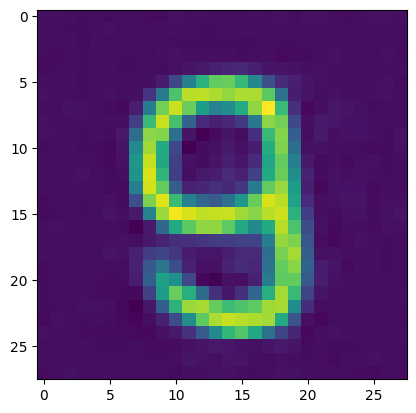

In [8]:
plt.imshow(recons[0].squeeze())

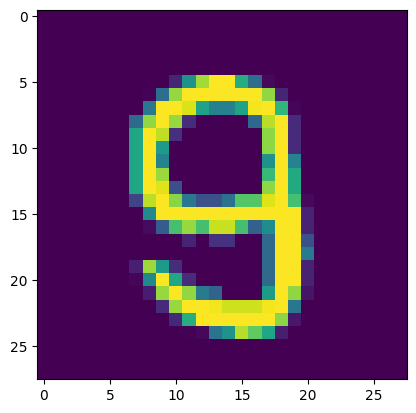

In [9]:
plt.imshow(data[0].squeeze())

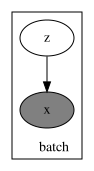

In [10]:
objects['monad'].render_model()

78it [00:11,  6.90it/s]


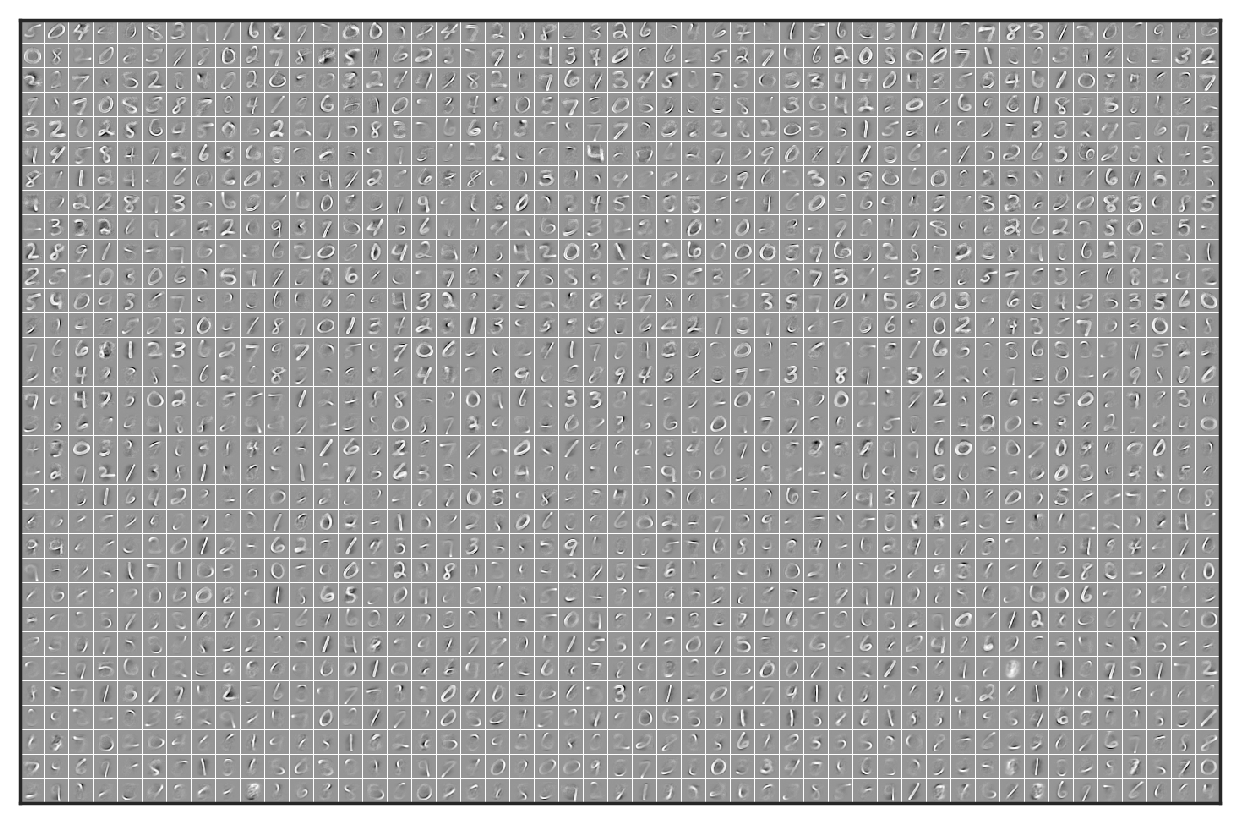

(<Figure size 1600x800 with 1 Axes>, <Axes: >)

In [11]:
u_final = objects["trainer"].proposal_us(objects["datamodule"], objects["monad"], max_steps=100)
u_order = np.argsort(u_final)
experiment.pvae_convergence.show_decoder(objects["datamodule"], objects["monad"].parameters, method="abs-max", order=u_order)

In [12]:
def r2(xs, xs_hat):
    squared_errors = ((xs - xs_hat) ** 2).sum()
    total_squares = ((xs - xs.mean(axis=0, keepdims=True)) ** 2).sum()
    return 1.0 - squared_errors / (total_squares + jnp.finfo("float64").eps)

def portion_zeros(zs):
    return (zs == 0).mean()

In [13]:
xs, xs_hat, zs = [], [], []

for data, _, _ in objects['datamodule'].test_dataloader():
    traces = objects['monad'](data)
    recons = traces['x'].mean(axis=0).reshape(data.shape[0], 1, 28, 28)
    xs.append(data)
    xs_hat.append(recons)
    zs.append(traces["z"])

xs = jnp.concatenate(xs, axis=0)
xs_hat = jnp.concatenate(xs_hat, axis=0)
zs = jnp.concatenate(zs, axis=1)

In [14]:
portion_zeros(zs)

Array(0.9196366, dtype=float32)

In [15]:
r2(xs, xs_hat)

Array(0.9016895, dtype=float32)

In [16]:
xs.shape

(9984, 1, 28, 28)

In [17]:
with hydra.initialize(version_base="1.3", config_path="../configs", job_name="eval"):
    cfg = hydra.compose(config_name="eval.yaml", overrides=["ckpt_path=logs/train/runs/2026-02-06_17-33-01/saved/checkpoint-epoch4000.npy",
                                                            "+experiment=pvae_fpi", "data=omniglot", "trainer._target_=src.trainer.PVaeTrainer",
                                                            "hydra.runtime.output_dir=logs/test"],
                        return_hydra_config=True)
    hydra.core.hydra_config.HydraConfig.instance().set_config(cfg)
    metrics, objects = test.test(cfg)

In [18]:
metrics

{'loss': np.float32(-28063.62),
 'loss_batch_mean': np.float32(-219.24702),
 'log_w': np.float32(24555.666),
 'log_w_batch_mean': np.float32(191.84114)}

In [19]:
for data, _, _ in objects['datamodule'].test_dataloader():
    recons = objects['monad'](data)['x'].mean(axis=0).reshape(data.shape[0], 1, 28, 28)
    break

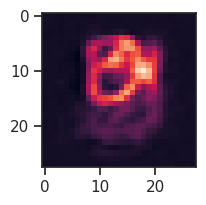

In [20]:
plt.imshow(recons[0].squeeze())

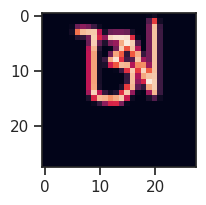

In [21]:
plt.imshow(data[0].squeeze())

102it [00:15,  6.52it/s]


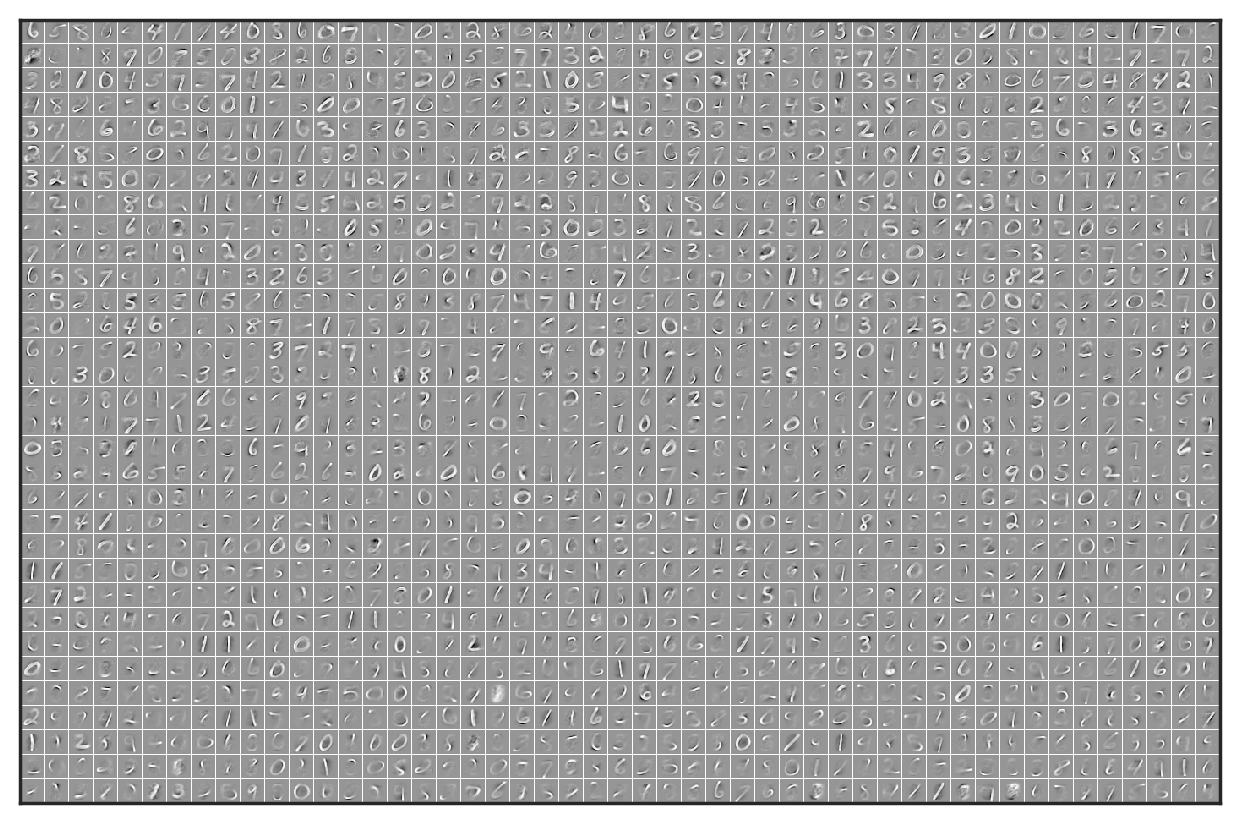

(<Figure size 1600x800 with 1 Axes>, <Axes: >)

In [22]:
u_final = objects["trainer"].proposal_us(objects["datamodule"], objects["monad"], max_steps=100)
u_order = np.argsort(u_final)
experiment.pvae_convergence.show_decoder(objects["datamodule"], objects["monad"].parameters, method="abs-max", order=u_order)

In [23]:
xs, xs_hat, zs = [], [], []

for data, _, _ in objects['datamodule'].test_dataloader():
    traces = objects['monad'](data)
    recons = traces['x'].mean(axis=0).reshape(data.shape[0], 1, 28, 28)
    xs.append(data)
    xs_hat.append(recons)
    zs.append(traces["z"])

xs = jnp.concatenate(xs, axis=0)
xs_hat = jnp.concatenate(xs_hat, axis=0)
zs = jnp.concatenate(zs, axis=1)

In [24]:
portion_zeros(zs)

Array(0.93023056, dtype=float32)

In [25]:
r2(xs, xs_hat)

Array(0.6234113, dtype=float32)

In [26]:
xs.shape

(13056, 1, 28, 28)

In [27]:
metrics = objects["trainer"].analysis(objects["datamodule"], objects["monad"], t_total=100)

15it [07:52, 31.53s/it]


In [28]:
metrics

{'du_norm': Array([44.65869  , 21.507093 , 16.531618 , 14.997619 , 14.657945 ,
        14.612848 , 14.627246 , 14.679631 , 14.741897 , 14.782534 ,
        14.798039 , 14.802494 , 14.806524 , 14.812523 , 14.819465 ,
        14.826213 , 14.832078 , 14.836783 , 14.840291 , 14.842814 ,
        14.844565 , 14.845738 , 14.846515 , 14.847021 , 14.8473625,
        14.847598 , 14.847813 , 14.848071 , 14.848391 , 14.848771 ,
        14.84919  , 14.849616 , 14.850014 , 14.850389 , 14.850722 ,
        14.851008 , 14.851287 , 14.851539 , 14.851787 , 14.852017 ,
        14.852235 , 14.852432 , 14.85262  , 14.8527775, 14.852913 ,
        14.853027 , 14.8531065, 14.853173 , 14.853223 , 14.853268 ,
        14.853305 , 14.853341 , 14.853382 , 14.853415 , 14.853445 ,
        14.8534775, 14.853505 , 14.853531 , 14.853552 , 14.853575 ,
        14.853594 , 14.853608 , 14.85363  , 14.853636 , 14.85365  ,
        14.8536625, 14.853675 , 14.853687 , 14.853703 , 14.853709 ,
        14.853713 , 14.853728 , 14.85

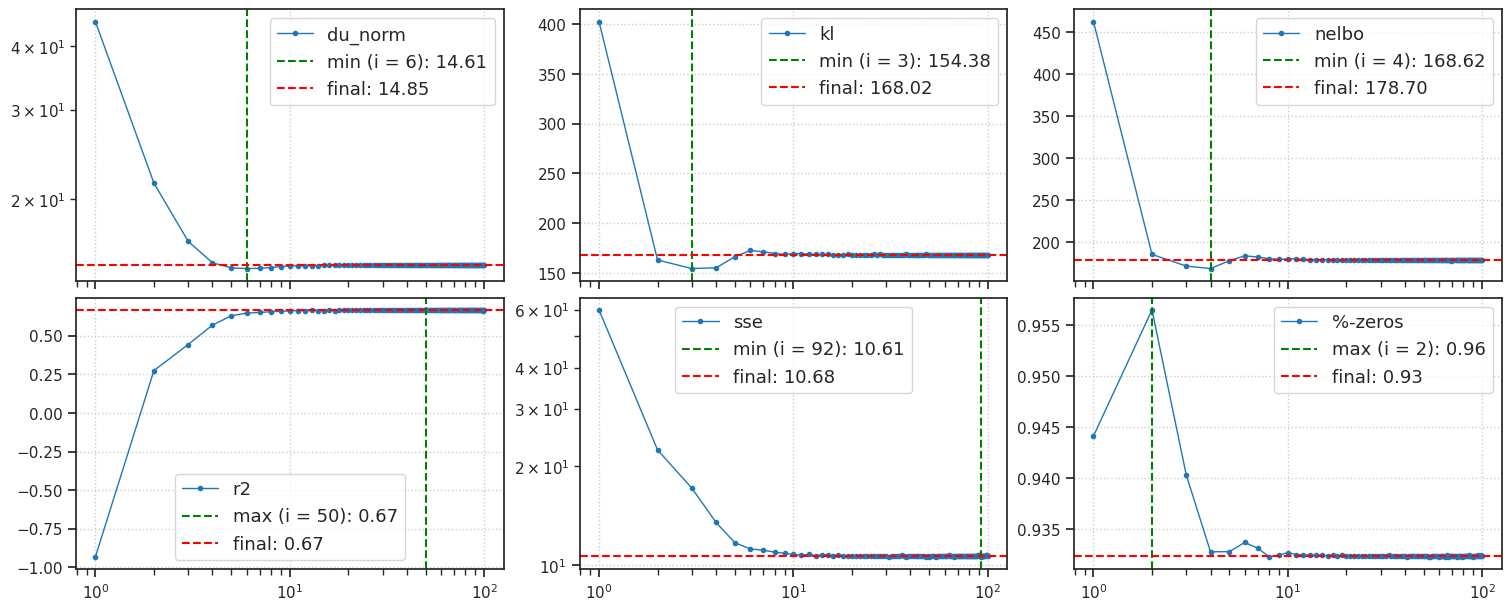

(<Figure size 1500x600 with 6 Axes>,
 array([[<Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >]], dtype=object))

In [29]:
experiment.plot_convergence(metrics)

In [30]:
with hydra.initialize(version_base="1.3", config_path="../configs", job_name="eval"):
    cfg = hydra.compose(config_name="eval.yaml", overrides=["ckpt_path=logs/train/runs/2026-02-06_17-33-01/saved/checkpoint-epoch4000.npy",
                                                            "+experiment=pvae_fpi", "data=emnist", "trainer._target_=src.trainer.PVaeTrainer",
                                                            "hydra.runtime.output_dir=logs/test"],
                        return_hydra_config=True)
    hydra.core.hydra_config.HydraConfig.instance().set_config(cfg)
    metrics, objects = test.test(cfg)

In [31]:
metrics

{'loss': np.float32(142150.8),
 'loss_batch_mean': np.float32(1110.5531),
 'log_w': np.float32(-124381.945),
 'log_w_batch_mean': np.float32(-971.73395)}

In [32]:
for data, _, _ in objects['datamodule'].test_dataloader():
    recons = objects['monad'](data)['x'].mean(axis=0).reshape(data.shape[0], 1, 28, 28)
    break

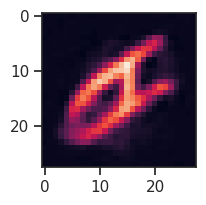

In [33]:
plt.imshow(recons[0].squeeze())

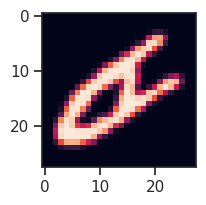

In [34]:
plt.imshow(data[0].squeeze())

146it [00:23,  6.26it/s]


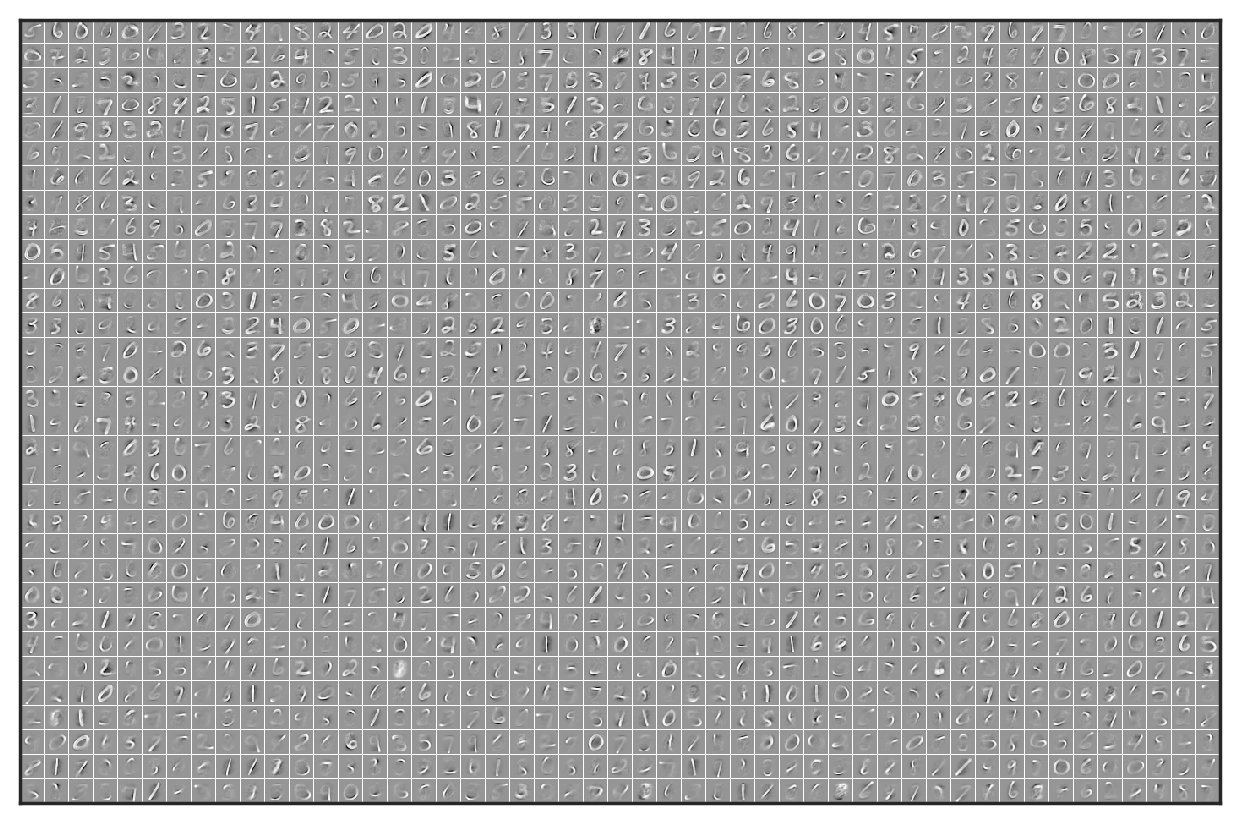

(<Figure size 1600x800 with 1 Axes>, <Axes: >)

In [35]:
u_final = objects["trainer"].proposal_us(objects["datamodule"], objects["monad"], max_steps=100)
u_order = np.argsort(u_final)
experiment.pvae_convergence.show_decoder(objects["datamodule"], objects["monad"].parameters, method="abs-max", order=u_order)

In [36]:
xs, xs_hat, zs = [], [], []

for data, _, _ in objects['datamodule'].test_dataloader():
    traces = objects['monad'](data)
    recons = traces['x'].mean(axis=0).reshape(data.shape[0], 1, 28, 28)
    xs.append(data)
    xs_hat.append(recons)
    zs.append(traces["z"])

xs = jnp.concatenate(xs, axis=0)
xs_hat = jnp.concatenate(xs_hat, axis=0)
zs = jnp.concatenate(zs, axis=1)

In [37]:
portion_zeros(zs)

Array(0.91501075, dtype=float32)

In [38]:
r2(xs, xs_hat)

Array(0.52795327, dtype=float32)

In [39]:
xs.shape

(18688, 1, 28, 28)

In [40]:
metrics = objects["trainer"].analysis(objects["datamodule"], objects["monad"], t_total=100)

88it [50:03, 34.13s/it]


In [41]:
metrics

{'du_norm': Array([44.848595, 22.40172 , 18.577625, 18.003082, 18.173784, 18.34737 ,
        18.436247, 18.480055, 18.505049, 18.51927 , 18.526573, 18.530445,
        18.532993, 18.535057, 18.536802, 18.53822 , 18.539278, 18.539991,
        18.540438, 18.540728, 18.54091 , 18.541044, 18.541126, 18.541176,
        18.541204, 18.541214, 18.541197, 18.541187, 18.541191, 18.54119 ,
        18.541195, 18.541212, 18.541224, 18.54123 , 18.541245, 18.541252,
        18.541264, 18.541275, 18.541283, 18.541286, 18.54129 , 18.541294,
        18.541292, 18.541292, 18.541294, 18.541294, 18.541294, 18.541294,
        18.541294, 18.54129 , 18.541292, 18.541294, 18.541292, 18.54129 ,
        18.541294, 18.541294, 18.541292, 18.54129 , 18.541292, 18.541292,
        18.541294, 18.541294, 18.541292, 18.541302, 18.541298, 18.541292,
        18.541296, 18.541298, 18.541294, 18.54129 , 18.541294, 18.541292,
        18.541294, 18.54129 , 18.541294, 18.541294, 18.54129 , 18.541292,
        18.541292, 18.54129

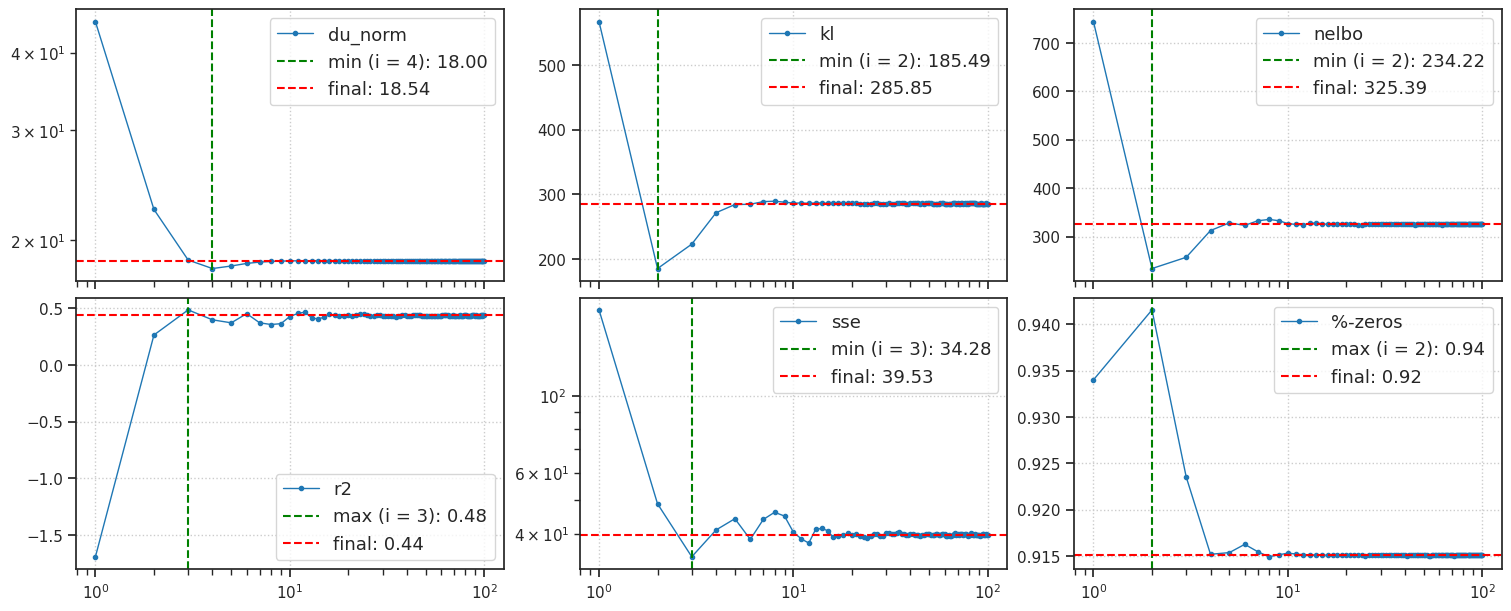

(<Figure size 1500x600 with 6 Axes>,
 array([[<Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >]], dtype=object))

In [42]:
experiment.plot_convergence(metrics)